# Pumpmodel coefficients
This notebook creates two regression models for the pumps. One for the pump pressure and one for the power. The provided result at the end are the coefficients of both characteristic polynoms. (Use the outline sidebar to navigate through this notebook)

- [Setup](#Setup)
- [Data](#Data)
- [Pressure regression](#Pressure-regression)
- [Power regression](#Power-regression)
- [Solution](#Solution)

### Setup

In [175]:
# Import all necessary packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import h5py as h5
from plotid.publish import publish
from plotid.tagplot import tagplot

from pathlib import Path
from statistics import mean
from charakterisierung_pruefstand.conversions import (
    voltage_to_power,
    voltage_to_pressure,
    voltage_to_volumeflow,
    pressure_to_head,
)
from charakterisierung_pruefstand.interactive import create_buttons
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

### Data
The follwoing section reads and converts the datafile of the pump charakterization, which includes the pressure from inlet to outlet of the pump, the pump power and the volume flow at the leakage pipeline.

#### Reading

In [176]:
# creates buttons to choose the data for the coefficients
file_names = [
    "data/data_2024-10-28_18-55-49_Kennlinie_Pumpe_1.h5",
    "data/data_2024-11-01_11-18-57_Kennlinie_Pumpe_2.h5",
]
h5py_data = create_buttons(choose=file_names, name="System curve files")

You selected: data/data_2024-10-28_18-55-49_Kennlinie_Pumpe_1.h5


In [177]:
# setting variables for different datafiles of pump 1 and pump 2
if "Pumpe_1" in h5py_data:
    pumpname = "Pumpe 1"
    P_max_power = 230
    # creates a list of rotational speed
    # rpm_list = np.array([0, 1400, 1836, 2271, 2707, 3143, 3579, 4014, 4450])
    rpm_list = np.array(
        [
            1836,
            2271,
            2707,
        ]
    )
else:
    pumpname = "Pumpe 2"
    P_max_power = 115
    # creates a list of rotational speed
    rpm_list = np.array([0, 1400, 1686, 1971, 2257, 2543, 2829, 3114, 3400])
# calculates the relative rotational speed
rpm_list = rpm_list / 4450  # np.max(rpm_list)

In [178]:
# reads the data from hdf5 file
with h5.File("{}".format(h5py_data), "r") as f:
    # creates two lists for pump speed names and valve opening names
    pump_speed = [
        "Pumpeneinstellung_1836",
        "Pumpeneinstellung_2271",
        "Pumpeneinstellung_2707",
    ]  # list(f["{}".format(pumpname)].keys())
    valve_openings = list(f["{}/{}".format(pumpname, pump_speed[0])].keys())
    # creates empty lists in lists for data
    power_data_raw = [[] for _ in pump_speed]
    pressure_data_raw = [[] for _ in pump_speed]
    volume_flow_raw = [[] for _ in pump_speed]
    # saves data in three differnt lists
    for i, speed in enumerate(pump_speed):
        for n, valve in enumerate(valve_openings):
            data = f["{}/{}/{}".format(pumpname, speed, valve)]
            pressure_datapoint = list(float(n) for n in data[1])
            volume_flow_datapoint = list(float(n) for n in data[2])
            power_datapoint = list(float(n) for n in data[0])
            pressure_data_raw[i].extend([pressure_datapoint])
            power_data_raw[i].extend([power_datapoint])
            volume_flow_raw[i].extend([volume_flow_datapoint])

#### Conversion

In [179]:
# creatses two lists and one list with lists inside
power_data_means = []
pressure_data_means = []
volume_flow_data_means = [[] for _ in pump_speed]
# converts the raw data, means the datapoints and adds each point in a list
# conversion of powerdata in W
for z, _ in enumerate(power_data_raw):
    for n, _ in enumerate(power_data_raw[z]):
        power_data_means.append(
            mean([voltage_to_power(k, P_max=P_max_power) for k in power_data_raw[z][n]])
        )
# conversion of volume flow data in l/min
for z, _ in enumerate(volume_flow_raw):
    for n, _ in enumerate(volume_flow_raw[z]):
        volume_flow_data_means[z].append(
            mean(
                [
                    voltage_to_volumeflow(k, Q_min=0, Q_max=100)
                    for k in volume_flow_raw[z][n]
                ]
            )
        )
# conversion of pressure data in meter
for z, _ in enumerate(pressure_data_raw):
    for n, _ in enumerate(pressure_data_raw[z]):
        pressure_data_means.append(
            mean(
                [
                    pressure_to_head(voltage_to_pressure(k, p_max=3))
                    for k in pressure_data_raw[z][n]
                ]
            )
        )

In [180]:
np.array(volume_flow_data_means).shape

(3, 11)

### Pressure regression
Below is the characteristic Polynom which defines the relationship between pressure, volume flow and rotational speed. This section determines the coefficients. 

$
H=a \cdot Q^2 + b \cdot n_{rel} \cdot Q + c \cdot n_{rel}^2
$

#### Model

In [181]:
# creates the X-data array for the model
X_pressure = []
# converts the volume flow data in m^3/h

volume_flow_data_means = np.array(volume_flow_data_means) / 1000 * 60
# creates a numpy array with the factors before the coefficients for each data point in row
for idx, q in enumerate(volume_flow_data_means):
    X_pressure.append(
        np.array([q**2, q * rpm_list[idx], np.ones(len(q)) * rpm_list[idx] ** 2]).T
    )
# connects the arrays
X_pressure = np.vstack(X_pressure)
# creats linear regression for the choosen data
pressure_model = LinearRegression(fit_intercept=False, tol=1e-8).fit(
    X_pressure, pressure_data_means
)

In [184]:
X_pressure.shape


(33, 3)

In [185]:
rpm_list

array([0.41258427, 0.51033708, 0.60831461])

In [186]:
volume_flow_data_means

array([[0.00223394, 0.02973062, 0.54748635, 0.10585334, 0.22584903,
        0.32203295, 0.40476023, 0.46284818, 0.50460675, 0.52324123,
        0.53885259],
       [0.00229054, 0.03979044, 0.70093002, 0.14660407, 0.29469851,
        0.4226255 , 0.51609306, 0.58845888, 0.64395558, 0.67078062,
        0.69190331],
       [0.00234311, 0.04845761, 0.8497878 , 0.18437259, 0.35897013,
        0.50828428, 0.62491133, 0.71287539, 0.77253326, 0.81383365,
        0.83923897]])

#### Plot
Creates a plot comparing the pressure model (shown as a line) with measured data (shown as dots).

In [170]:
# configuration of plot with fst style
# plt.style.use(Path().resolve().parent / "plot_setup/FST.mplstyle")
mpl.rcParams.update(
    {
        "mathtext.fontset": "dejavuserif",
        "font.size": 12,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 14,
    }
)

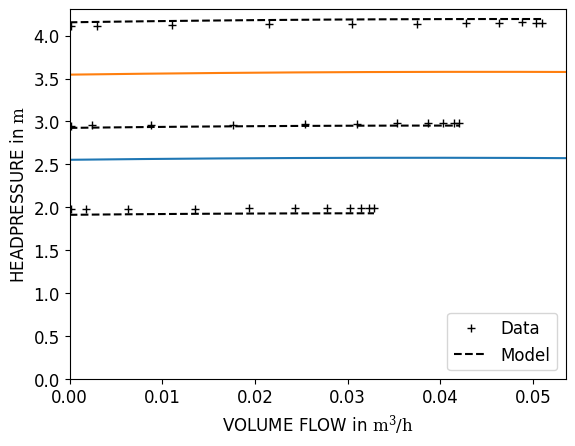

In [171]:
# splits the array in 9 arrays with 11 entries
pressure_data_means_reshape = np.array(pressure_data_means).reshape(-1, 11)
fig, ax = plt.subplots()
# creates a loop over the differnt speeds
for i, rpm in enumerate(rpm_list):
    # creates plots of the datapoints for each speed
    ax.plot(
        volume_flow_data_means[i],
        pressure_data_means_reshape[i],
        "+",
        color="black",
        mfc="white",
        zorder=2,
    )
    # creats 100 points between 0 and max volume data value
    q_test_pressure = np.linspace(0, max(volume_flow_data_means[i]), 100)
    # calculates the factors for the equation and sves them into an array
    X_test_pressure = np.array(
        [
            q_test_pressure**2,
            q_test_pressure * rpm,
            np.ones(len(q_test_pressure)) * rpm**2,
        ]
    ).T
    # use the predict function of the linear regression feature to predict the headpressure
    y_pred_pressure = pressure_model.predict(X_test_pressure)
    # plots the predicted head pressure
    ax.plot(q_test_pressure, y_pred_pressure, "--", color="black", zorder=1)

ax.set_ylabel(r"HEADPRESSURE in $\mathrm{m}$")
ax.set_xlabel(r"VOLUME FLOW in $\mathrm{m^3/h}$")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(["Data", "Model"], loc=4, frameon=True)
k1, k2, k3 = pressure_model.coef_

s_1 = 35.36 / 74.16
s_2 = 41.67 / 74.16
ax.plot(
    np.linspace(0.0, 0.8, 100),
    [(k1 * q**2 + k2 * q * s_1 + k3 * s_1**2) for q in np.linspace(0.0, 0.8, 100)],
)

ax.plot(
    np.linspace(0.0, 0.8, 100),
    [(k1 * q**2 + k2 * q * s_2 + k3 * s_2**2) for q in np.linspace(0.0, 0.8, 100)],
)

# publish(
#     tagplot(
#         fig,
#         "matplotlib",
#         id_method="time",
#     ),
#     [
#         "../data/{}".format(h5py_data),
#         "../charakterisierung_pruefstand",
#         "Pump_coefficients.ipynb",
#     ],
#     "../plots",
# )

In [165]:
k3

np.float64(10.683766557142663)

In [158]:
print(volume_flow_data_means)

[[0.00223394 0.02973062 0.54748635 0.10585334 0.22584903 0.32203295
  0.40476023 0.46284818 0.50460675 0.52324123 0.53885259]
 [0.00229054 0.03979044 0.70093002 0.14660407 0.29469851 0.4226255
  0.51609306 0.58845888 0.64395558 0.67078062 0.69190331]
 [0.00234311 0.04845761 0.8497878  0.18437259 0.35897013 0.50828428
  0.62491133 0.71287539 0.77253326 0.81383365 0.83923897]]


### Power regression
Below is the characteristic Polynom which defines the relationship between power, volume flow and rotational speed. This section determines the coefficients. 

$
P=a \cdot Q^3 + b \cdot n_{rel} \cdot Q^2 + c \cdot n_{rel}^2 \cdot Q + d \cdot n_{rel}^3
$


#### Model

In [159]:
X_power = []
# creates a numpy array with the factors before the coefficients for each data point in row
for idx, q in enumerate(volume_flow_data_means):
    X_power.append(
        np.array(
            [
                q**3,
                q**2 * rpm_list[idx],
                q * rpm_list[idx] ** 2,
                np.ones(len(q)) * rpm_list[idx] ** 3,
            ]
        ).T
    )
# connects the arrays
X_power = np.vstack(X_power)

In [160]:
# creates linear regression with powerdata and volumne flow
y_power = np.array(power_data_means)
power_model = LinearRegression(fit_intercept=True).fit(X_power, y_power)

#### Plot
Creates a plot comparing the pressure model (shown as a line) with measured data (shown as dots).

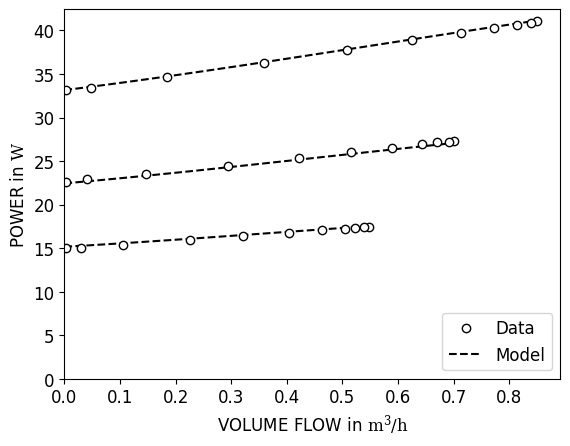

In [161]:
# splits the array in 9 arrays with 11 entries
y_power_reshape = y_power.reshape(-1, 11)
# creates a loop over the differnt speeds
for i, rpm in enumerate(rpm_list):
    # creates plots of the datapoints for each speed
    plt.plot(
        volume_flow_data_means[i],
        y_power_reshape[i],
        "o",
        color="black",
        mfc="white",
        zorder=2,
    )
    # creats 100 points between 0 and max volume data value
    q_test_power = np.linspace(0, max(volume_flow_data_means[i]), 100)
    # calculates the factors for the equation and sves them into an array
    X_test_power = np.array(
        [
            q_test_power**3,
            q_test_power**2 * rpm,
            q_test_power * rpm**2,
            np.ones(len(q_test_power)) * rpm**3,
        ]
    ).T
    # use the predict function of the linear regression feature to predict the power
    y_pred_power = power_model.predict(X_test_power)
    # plots the predicted power
    plt.plot(q_test_power, y_pred_power, "--", color="black", zorder=1)
    plt.ylabel(r"POWER in $\mathrm{W}$")
plt.xlabel(r"VOLUME FLOW in $\mathrm{m^3/h}$")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(["Data", "Model"], loc=4, frameon=True)
# publish(
#     tagplot(
#         fig,
#         "matplotlib",
#         id_method="time",
#     ),
#     [
#         "../data/{}".format(h5py_data),
#         "../charakterisierung_pruefstand",
#         "Pump_coefficients.ipynb",
#     ],
#     "../plots",
# )

### Solution

In [162]:
print("pressure model coefficients:", pressure_model.coef_)
print("pressure model intercept:", pressure_model.intercept_)
print("pressure model score:", pressure_model.score(X_pressure, pressure_data_means))
print("power model coefficients:", power_model.coef_)
print("power model intercept:", power_model.intercept_)
print("power model score:", power_model.score(X_power, y_power))

pressure model coefficients: [-8.53462945e-04  8.32879243e-02  1.06837666e+01]
pressure model intercept: 0.1614022793194052
pressure model score: 0.999959774984361
power model coefficients: [ -2.21130902   5.92154386  21.42158899 116.15839292]
power model intercept: 7.005185419807162
power model score: 0.9996611112091675
